# Practical case: wood pallet carbon footprint

Supporting notebook for the wood-pallet environmental case.

The model is simulated with 100,000 Monte Carlo observations. Truck type is sampled with the **equal 1/3 probabilities used in the published model**, and end-of-life state with equal probabilities. The two discrete inputs are stored as pandas categorical variables so that `heterogeneity_indices()` uses their natural states when they define regions.

In [1]:
!pip install simdec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.1/800.1 kB 18.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display


import json
from importlib.metadata import distribution, version

import simdec as sd

assert callable(getattr(sd, "sensitivity_indices", None))
assert callable(getattr(sd, "heterogeneity_indices", None))

dist = distribution("simdec")
print("SimDec version:", version("simdec"))
print("SimDec module:", sd.__file__)

direct_url = dist.read_text("direct_url.json")
if direct_url:
    print("Installation provenance:")
    print(json.dumps(json.loads(direct_url), indent=2))
else:
    print("No direct_url.json was found for this installation.")


N_RUNS = 100_000
N_REGIONS = 5
SEED = 20260913
SI_COLOR = "#173F6D"
H_COLOR = "#8B3F3F"

SimDec version: 1.5.2
SimDec module: /usr/local/lib/python3.13/dist-packages/simdec/__init__.py
No direct_url.json was found for this installation.


In [3]:
GWP_TIMBER = 0.16
GWP_NAILS = 3.47
GWP_ELECTRICITY = 0.175
GWP_THERMAL = 0.019
TRUCK_GWP = {1: 0.076, 2: 0.084, 3: 0.121}
EOL_GWP = {1: -23.8, 2: 31.5}


def lognormal_mu_sigma(mean, sd):
    sigma = np.sqrt(np.log((mean**2 + sd**2) / mean**2))
    mu = np.log(mean**2 / np.sqrt(mean**2 + sd**2))
    return mu, sigma


def simulate_wood_case(n=N_RUNS, seed=SEED):
    rng = np.random.default_rng(seed)

    pars = {
        "Timber": lognormal_mu_sigma(21.9, 6.9),
        "Nails": lognormal_mu_sigma(0.35, 0.11),
        "Electricity": lognormal_mu_sigma(0.69, 0.73),
        "Thermal energy": lognormal_mu_sigma(4.1, 2.5),
    }

    X = pd.DataFrame({
        "Timber": rng.lognormal(*pars["Timber"], n),
        "Nails": rng.lognormal(*pars["Nails"], n),
        "Electricity": rng.lognormal(*pars["Electricity"], n),
        "Thermal energy": rng.lognormal(*pars["Thermal energy"], n),
        "Number of uses": rng.uniform(1, 83, n),
        "Transportation distance": rng.uniform(100, 200, n),
        "Truck type": rng.choice(
            [1, 2, 3],
            size=n,
            p=[1/3, 1/3, 1/3],
        ),
        "End of life": rng.choice(
            [1, 2],
            size=n,
            p=[0.5, 0.5],
        ),
    })

    truck_gwp = X["Truck type"].map(TRUCK_GWP).to_numpy()
    eol_gwp = X["End of life"].map(EOL_GWP).to_numpy()

    uses = X["Number of uses"].to_numpy()
    n_pallets = 1000 / uses

    one_pallet = (
        X["Timber"].to_numpy() * GWP_TIMBER
        + X["Nails"].to_numpy() * GWP_NAILS
        + X["Electricity"].to_numpy() * GWP_ELECTRICITY
        + X["Thermal energy"].to_numpy() * GWP_THERMAL
    )

    production = one_pallet * 1000 / uses

    mass = (
        X["Timber"].to_numpy() * 0.98
        + X["Nails"].to_numpy()
    )

    repair = (
        1.23 * GWP_TIMBER
        + 0.056 * GWP_NAILS
        + 1.16 * GWP_ELECTRICITY
    ) * 2 * n_pallets

    transportation = (
        n_pallets
        * mass
        * (X["Transportation distance"].to_numpy() * 2)
        * truck_gwp
        / 1000
        * uses
    )

    end_of_life = n_pallets * eol_gwp

    y = pd.Series(
        production
        + repair
        + transportation
        + end_of_life,
        name="Total GWP",
    )

    return X, y

X_numeric, y_wood = simulate_wood_case()

# Tell the heterogeneity function that the discrete numerical codes are categories.
X_wood = X_numeric.copy()
X_wood["Truck type"] = pd.Categorical(X_wood["Truck type"], categories=[1, 2, 3])
X_wood["End of life"] = pd.Categorical(X_wood["End of life"], categories=[1, 2])
print("Runs:", len(y_wood))
display(X_wood.head())

Runs: 100000


,Timber,Nails,Electricity,Thermal energy,Number of uses,Transportation distance,Truck type,End of life
0,11.046130,0.234078,0.399615,1.706517,76.401853,129.293523,2,2
1,16.119609,0.518181,1.658363,1.289708,45.387898,143.236228,1,2
2,17.478756,0.443285,0.464767,2.724755,80.923665,117.963295,2,1
3,28.326080,0.397840,0.086250,2.335929,26.595891,160.396184,2,2
4,15.985485,0.301574,0.239194,8.116351,62.496029,110.334262,1,1


In [4]:
# Raw global combined sensitivity uses the numeric representation.
global_est = sd.sensitivity_indices(inputs=X_numeric, output=y_wood)
global_si = pd.Series(np.asarray(global_est.si, dtype=float).ravel(), index=X_numeric.columns, name="S_i")

# Full package scan: H_Y and H_Xi in one call.
H = sd.heterogeneity_indices(output=y_wood, inputs=X_wood, n_regions=N_REGIONS)
summary = pd.DataFrame({"S_i": global_si, "H_Xi": H.indices.reindex(X_numeric.columns)})
display(summary.style.format("{:.4f}"))
print("H_Y:", H.indices["Y"])
print("Raw global SI sum:", global_si.sum())

# Discrete inputs must be absent from their own regional profiles.
assert "Truck type" not in H.details["Truck type"].raw_profiles.columns
assert "End of life" not in H.details["End of life"].raw_profiles.columns

/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:57: RuntimeWarning: invalid value encountered in multiply
  return bound(*args, **kwds)
/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:57: RuntimeWarning: invalid value encountered in divide
  return bound(*args, **kwds)
/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:57: RuntimeWarning: invalid value encountered in multiply
  return bound(*args, **kwds)
/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:57: RuntimeWarning: invalid value encountered in divide
  return bound(*args, **kwds)


,S_i,H_Xi
Timber,0.0117,0.0370
Nails,0.0037,0.0220
Electricity,0.0035,0.0180
Thermal energy,0.0042,0.0299
Number of uses,0.3034,0.1972
Transportation distance,0.0049,0.0365
Truck type,0.0020,0.0189
End of life,0.4372,0.0295


H_Y: 0.5429294273324403
Raw global SI sum: 0.7706532946560597


## Figure 8

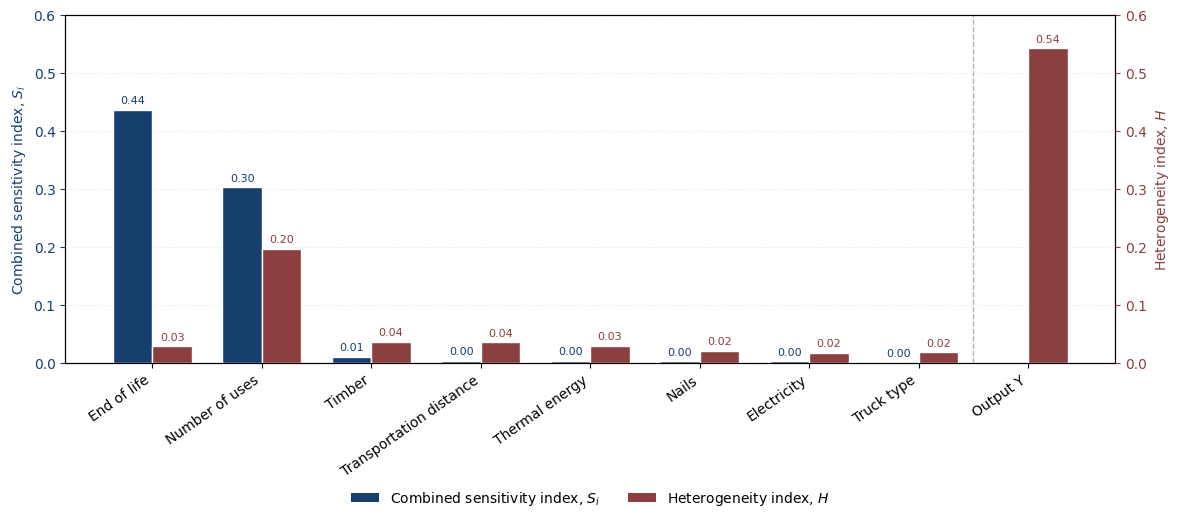

In [5]:
order = global_si.sort_values(ascending=False).index.tolist()
labels = order + ["Output Y"]
S_plot = np.r_[global_si.loc[order].to_numpy(float), np.nan]
H_plot = np.r_[H.indices.loc[order].to_numpy(float), H.indices["Y"]]
x = np.arange(len(labels))
fig, ax_s = plt.subplots(figsize=(12.5, 5.8))
ax_h = ax_s.twinx()
width = 0.36
bs = ax_s.bar(x-width/2, S_plot, width, color=SI_COLOR, edgecolor="white")
bh = ax_h.bar(x+width/2, H_plot, width, color=H_COLOR, edgecolor="white")
ax_s.set_ylim(0, 0.60); ax_h.set_ylim(0, 0.60)
ax_s.set_ylabel(r"Combined sensitivity index, $S_i$", color=SI_COLOR)
ax_h.set_ylabel(r"Heterogeneity index, $H$", color=H_COLOR)
ax_s.tick_params(axis="y", colors=SI_COLOR); ax_h.tick_params(axis="y", colors=H_COLOR)
ax_s.set_xticks(x); ax_s.set_xticklabels(labels, rotation=35, ha="right")
ax_s.axvline(len(order)-0.5, color="0.70", linestyle="--", linewidth=1)
ax_s.grid(axis="y", linestyle=":", alpha=0.30); ax_s.set_axisbelow(True)
for b, v in zip(bs, S_plot):
    if np.isfinite(v): ax_s.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.2f}", ha="center", fontsize=8, color=SI_COLOR)
for b, v in zip(bh, H_plot):
    if np.isfinite(v): ax_h.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.2f}", ha="center", fontsize=8, color=H_COLOR)
fig.legend(handles=[Patch(facecolor=SI_COLOR, label=r"Combined sensitivity index, $S_i$"), Patch(facecolor=H_COLOR, label=r"Heterogeneity index, $H$")], loc="lower center", bbox_to_anchor=(0.5, 0.01), ncol=2, frameon=False)
fig.subplots_adjust(bottom=0.28, left=0.08, right=0.92)
plt.show()

Figure 8: Combined sensitivity and heterogeneity indices for the wooden-pallet carbon-footprint mode

## Figure 9

Selected profiles: ['Y', 'Number of uses', 'End of life']


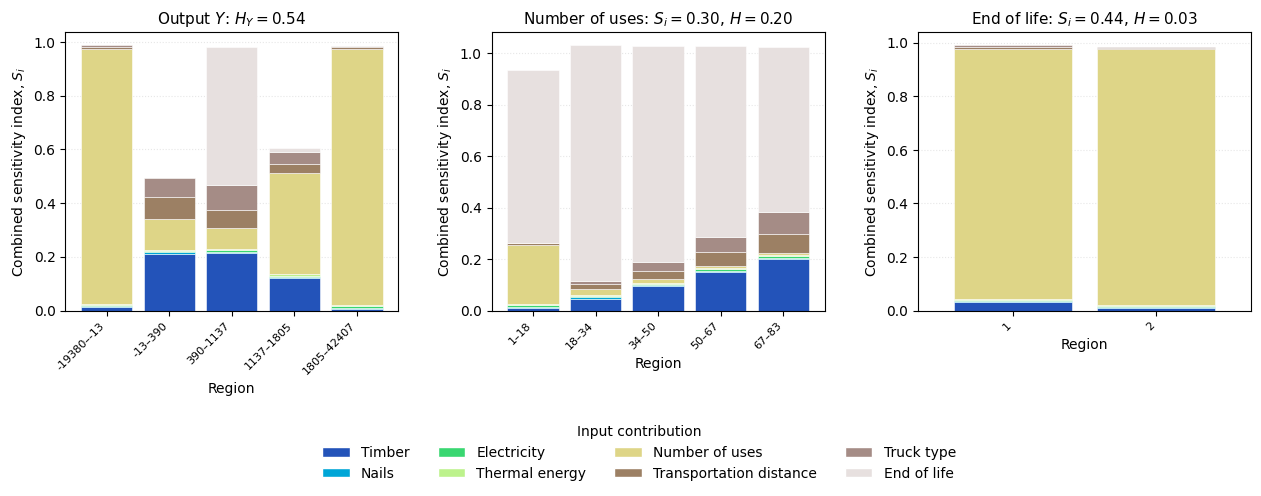

In [6]:
selected = ["Y"] + [
    v for v in X_numeric.columns
    if (H.indices[v] >= 0.10 or global_si[v] >= 0.30)
]

selected = list(dict.fromkeys(selected))
print("Selected profiles:", selected)

cmap = plt.colormaps["terrain"]
colors = {
    name: cmap(pos)
    for name, pos in zip(
        X_numeric.columns,
        np.linspace(0.05, 0.95, len(X_numeric.columns)),
    )
}

def format_region_label(region):
    if isinstance(region, pd.Interval):
        return f"{region.left:.0f}–{region.right:.0f}"
    if isinstance(region, (int, float, np.integer, np.floating)):
        return f"{region:.0f}"
    return str(region)

fig, axes = plt.subplots(
    1,
    len(selected),
    figsize=(5.1 * len(selected), 4.8),
    squeeze=False,
)

for ax, name in zip(axes.ravel(), selected):
    raw = H.details[name].raw_profiles

    raw.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[colors[c] for c in raw.columns],
        edgecolor="white",
        linewidth=0.4,
        width=0.82,
        legend=False,
    )

    title = (
        rf"Output $Y$: $H_Y={H.indices[name]:.2f}$"
        if name == "Y"
        else rf"{name}: $S_i={global_si[name]:.2f}$, $H={H.indices[name]:.2f}$"
    )

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Region")
    ax.set_ylabel(r"Combined sensitivity index, $S_i$")

    ax.set_xticklabels(
        [format_region_label(region) for region in raw.index],
        rotation=45,
        ha="right",
        fontsize=8,
    )

    ax.grid(axis="y", linestyle=":", alpha=0.30)
    ax.set_axisbelow(True)

fig.legend(
    handles=[
        Patch(
            facecolor=colors[n],
            edgecolor="white",
            label=n,
        )
        for n in X_numeric.columns
    ],
    title="Input contribution",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=4,
    frameon=False,
)

fig.subplots_adjust(
    bottom=0.30,
    wspace=0.28,
)


plt.show()

Figure 9: Selected raw regional sensitivity profiles for the wooden-pallet carbon-footprint model. Profiles are shown
for the output 𝑌 and for inputs having either 𝐻𝑋𝑖 ≥ 0.10 or 𝑆𝑖 ≥ 0.30. The values of 𝐻 are calculated from normalized
regional sensitivity profiles, while raw profiles are displayed here to retain information on regional explainability.